# 🩹 Wound Classification - Retrain Model

This notebook **only retrains the Classification model** using your existing cropped data.

**Prerequisites:**
- ✅ Segmentation model already trained
- ✅ Cropped classification data already exists

---

## Cell 1: Imports

In [1]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.amp import GradScaler, autocast
from torchvision import transforms, datasets, models

# Check device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {DEVICE}")

if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

✅ Using device: cpu


## Cell 2: Configuration ⚙️

### 👇 EDIT THE NUMBER OF EPOCHS HERE! 👇

In [2]:
# =============================================================================
# ⚙️ CONFIGURATION - EDIT HERE!
# =============================================================================

# 👇👇👇 CHANGE NUMBER OF EPOCHS HERE 👇👇👇
NUM_EPOCHS = 30  # <-- EDIT THIS! (5=fast test, 30=good, 50=best)
# 👆👆👆 CHANGE NUMBER OF EPOCHS HERE 👆👆👆

# Paths (already set for your PC)
CROPPED_DATA_DIR = r"C:\Users\PC\Desktop\GraduationProject\MyProjectSTILL\FirstTry\outputs\cropped_classification_data"
MODEL_SAVE_DIR = r"C:\Users\PC\Desktop\GraduationProject\MyProjectSTILL\FirstTry\outputs\models"

# Training settings
BATCH_SIZE = 32
LEARNING_RATE = 1e-4
IMAGE_SIZE = 224

# Create model directory if not exists
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

print("="*60)
print("⚙️ CONFIGURATION")
print("="*60)
print(f"   Epochs:        {NUM_EPOCHS}")
print(f"   Batch size:    {BATCH_SIZE}")
print(f"   Learning rate: {LEARNING_RATE}")
print(f"   Device:        {DEVICE}")
print(f"   Data path:     {CROPPED_DATA_DIR}")
print(f"   Model path:    {MODEL_SAVE_DIR}")
print("="*60)

⚙️ CONFIGURATION
   Epochs:        30
   Batch size:    32
   Learning rate: 0.0001
   Device:        cpu
   Data path:     C:\Users\PC\Desktop\GraduationProject\MyProjectSTILL\FirstTry\outputs\cropped_classification_data
   Model path:    C:\Users\PC\Desktop\GraduationProject\MyProjectSTILL\FirstTry\outputs\models


## Cell 3: Data Transforms & Augmentation

In [3]:
def get_train_transforms():
    """Training transforms with augmentation."""
    return transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.RandomCrop(IMAGE_SIZE),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.3),
        transforms.RandomRotation(degrees=30),
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

def get_val_transforms():
    """Validation transforms (no augmentation)."""
    return transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

print("✅ Transforms defined!")

✅ Transforms defined!


## Cell 4: Load Datasets

In [4]:
print("📂 Loading datasets...")

# Load training data
train_dataset = datasets.ImageFolder(
    root=os.path.join(CROPPED_DATA_DIR, 'Train'),
    transform=get_train_transforms()
)

# Load validation data
val_dataset = datasets.ImageFolder(
    root=os.path.join(CROPPED_DATA_DIR, 'Valid'),
    transform=get_val_transforms()
)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"\n✅ Datasets loaded!")
print(f"   Train samples:      {len(train_dataset)}")
print(f"   Validation samples: {len(val_dataset)}")
print(f"   Classes:            {train_dataset.classes}")
print(f"   Train batches:      {len(train_loader)}")
print(f"   Val batches:        {len(val_loader)}")

📂 Loading datasets...

✅ Datasets loaded!
   Train samples:      700
   Validation samples: 170
   Classes:            ['infected', 'non-infected']
   Train batches:      22
   Val batches:        6


## Cell 5: Create EfficientNet-B0 Model

In [5]:
def create_efficientnet_classifier(num_classes=2, pretrained=True):
    """Create EfficientNet-B0 with custom classifier head."""
    if pretrained:
        weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1
        model = models.efficientnet_b0(weights=weights)
    else:
        model = models.efficientnet_b0(weights=None)
    
    # Replace classifier head
    num_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(num_features, 512),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.3),
        nn.Linear(512, num_classes)
    )
    
    return model

# Create model
print("🏗️ Creating EfficientNet-B0 model...")
model = create_efficientnet_classifier(num_classes=2, pretrained=True)
model = model.to(DEVICE)

print(f"✅ Model created!")
print(f"   Parameters: {sum(p.numel() for p in model.parameters()):,}")

🏗️ Creating EfficientNet-B0 model...
✅ Model created!
   Parameters: 4,664,446


## Cell 6: Training Function

In [6]:
def train_model(model, train_loader, val_loader, num_epochs, save_path):
    """
    Train the classification model.
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)
    
    # Mixed precision for GPU
    use_amp = DEVICE.type == 'cuda'
    scaler = GradScaler('cuda') if use_amp else None
    
    best_acc = 0.0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    print(f"\n{'='*60}")
    print(f"🚀 STARTING TRAINING ({num_epochs} epochs)")
    print(f"{'='*60}\n")
    
    for epoch in range(num_epochs):
        # ===================== TRAINING =====================
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        
        for batch_idx, (images, labels) in enumerate(train_loader):
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            
            optimizer.zero_grad()
            
            if use_amp:
                with autocast('cuda'):
                    outputs = model(images)
                    loss = criterion(outputs, labels)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
            
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()
            train_loss += loss.item()
            
            # Progress update every 10 batches
            if (batch_idx + 1) % 10 == 0:
                print(f"  Epoch {epoch+1}/{num_epochs} | Batch {batch_idx+1}/{len(train_loader)} | Loss: {loss.item():.4f} | Acc: {100.*train_correct/train_total:.1f}%")
        
        train_loss /= len(train_loader)
        train_acc = 100. * train_correct / train_total
        
        # ===================== VALIDATION =====================
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(DEVICE, non_blocking=True)
                labels = labels.to(DEVICE, non_blocking=True)
                
                if use_amp:
                    with autocast('cuda'):
                        outputs = model(images)
                        loss = criterion(outputs, labels)
                else:
                    outputs = model(images)
                    loss = criterion(outputs, labels)
                
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()
                val_loss += loss.item()
        
        val_loss /= len(val_loader)
        val_acc = 100. * val_correct / val_total
        
        # Update scheduler
        scheduler.step()
        
        # Save history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        # Print epoch summary
        print(f"\n📊 Epoch [{epoch+1}/{num_epochs}] Summary:")
        print(f"   Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"   Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
        
        # Save best model
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc,
                'val_loss': val_loss,
            }, save_path)
            print(f"   ✅ NEW BEST MODEL SAVED! (Acc: {val_acc:.2f}%)")
        
        print("-" * 60)
    
    print(f"\n{'='*60}")
    print(f"🏁 TRAINING COMPLETE!")
    print(f"{'='*60}")
    print(f"   Best Validation Accuracy: {best_acc:.2f}%")
    print(f"   Model saved to: {save_path}")
    
    return history, best_acc

print("✅ Training function defined!")

✅ Training function defined!


---
# 🏃 Cell 7: START TRAINING!

Run this cell to start training with the number of epochs you set in Cell 2.

---

In [7]:
# Path to save the model
model_save_path = os.path.join(MODEL_SAVE_DIR, 'classification_efficientnet.pth')

# Train the model!
history, best_accuracy = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=NUM_EPOCHS,
    save_path=model_save_path
)

print(f"\n🏆 Final Best Accuracy: {best_accuracy:.2f}%")


🚀 STARTING TRAINING (30 epochs)

  Epoch 1/30 | Batch 10/22 | Loss: 0.6404 | Acc: 54.7%
  Epoch 1/30 | Batch 20/22 | Loss: 0.6217 | Acc: 59.8%

📊 Epoch [1/30] Summary:
   Train Loss: 0.6513 | Train Acc: 61.29%
   Val Loss:   0.7056 | Val Acc:   67.65%
   ✅ NEW BEST MODEL SAVED! (Acc: 67.65%)
------------------------------------------------------------
  Epoch 2/30 | Batch 10/22 | Loss: 0.5771 | Acc: 73.1%
  Epoch 2/30 | Batch 20/22 | Loss: 0.6536 | Acc: 73.9%

📊 Epoch [2/30] Summary:
   Train Loss: 0.5730 | Train Acc: 74.43%
   Val Loss:   0.6719 | Val Acc:   73.53%
   ✅ NEW BEST MODEL SAVED! (Acc: 73.53%)
------------------------------------------------------------
  Epoch 3/30 | Batch 10/22 | Loss: 0.6280 | Acc: 76.6%
  Epoch 3/30 | Batch 20/22 | Loss: 0.3593 | Acc: 79.5%

📊 Epoch [3/30] Summary:
   Train Loss: 0.4981 | Train Acc: 79.00%
   Val Loss:   0.6488 | Val Acc:   73.53%
------------------------------------------------------------
  Epoch 4/30 | Batch 10/22 | Loss: 0.4469 | 

## Cell 8: Plot Training History

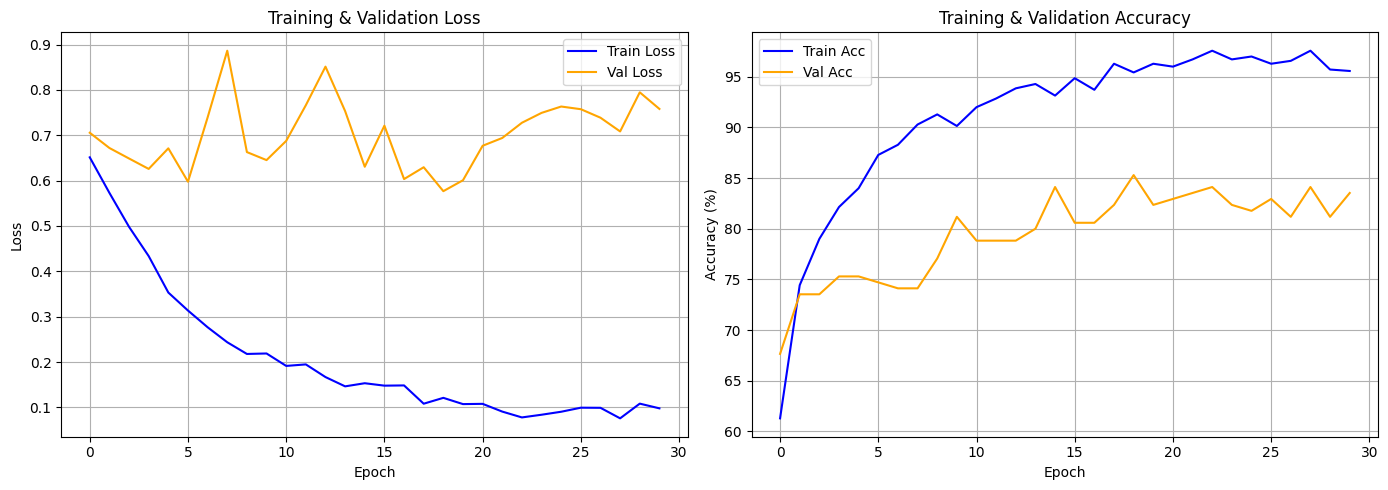


📊 Training history saved to: C:\Users\PC\Desktop\GraduationProject\MyProjectSTILL\FirstTry\outputs\models\training_history.png


In [8]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(history['train_loss'], label='Train Loss', color='blue')
axes[0].plot(history['val_loss'], label='Val Loss', color='orange')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy plot
axes[1].plot(history['train_acc'], label='Train Acc', color='blue')
axes[1].plot(history['val_acc'], label='Val Acc', color='orange')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training & Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_SAVE_DIR, 'training_history.png'), dpi=150)
plt.show()

print(f"\n📊 Training history saved to: {os.path.join(MODEL_SAVE_DIR, 'training_history.png')}")

---
# ✅ Training Complete!

Your model is saved at:
```
C:\Users\PC\Desktop\GraduationProject\MyProjectSTILL\FirstTry\outputs\models\classification_efficientnet.pth
```

---

## Cell 9: Load Best Model & Check Accuracy

In [9]:
# Load the best model
checkpoint = torch.load(model_save_path, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(DEVICE)
model.eval()

print("="*60)
print("📊 FINAL MODEL SUMMARY")
print("="*60)
print(f"   Best Epoch:      {checkpoint['epoch'] + 1}")
print(f"   Val Accuracy:    {checkpoint['val_acc']:.2f}%")
print(f"   Val Loss:        {checkpoint['val_loss']:.4f}")
print(f"   Model saved at:  {model_save_path}")
print("="*60)

📊 FINAL MODEL SUMMARY
   Best Epoch:      19
   Val Accuracy:    85.29%
   Val Loss:        0.5768
   Model saved at:  C:\Users\PC\Desktop\GraduationProject\MyProjectSTILL\FirstTry\outputs\models\classification_efficientnet.pth
